<a href="https://colab.research.google.com/github/aryanboruah/PHCCO-Summer-Training-Program-2026-/blob/main/AB_chromatin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A/B Compartments Chromatin Polymer Simulation

## Introduction

 **A/B compartments chromatin polymer** discussed here is a minimal block-copolymer model for chromatin. Here, chromatin beads are of A or B type representing the A/B compartments. The attractive interactions between A-A, B-B and A-B beads can be varied to get different chromatin configurations.

### Potential Energy and Interactions

In our simulation, the total potential energy of the polymer is calculated using two key interactions:

$$E =  \sum_{i=1}^{N-1}E_{\rm spring}(r_{i,i+1}) + \sum_{i=1}^{N-2}\sum_{j=i+2}^{N} E_{\rm LJ}(\epsilon_{ij},r_{i,j})$$


1. **Lennard-Jones (WCA) Potential**: This potential describes the interaction between non-bonded beads. It includes a repulsive term that prevents the beads from coming too close (modeling the excluded volume effect) and an attractive term that mimics van der Waals forces. The LJ potential is truncated at a cutoff distance to reduce computational cost:
   
$$
E_{\rm LJ}(r) =
\begin{cases}
4\epsilon_{ij}\left[\left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^6 \right] - E_{\rm cut}, & \text{if } r < 2.5 \sigma \\
0, & \text{if } r \geq 2.5 \sigma
\end{cases}
$$
   
   
   
   where  $\epsilon_{ij}$  is the interaction strength between the chromatin beads $i$ and $j$ ($\epsilon_{ij}\in \{\epsilon_{AA}, \epsilon_{AB}, \epsilon_{BB}\}$ depending on the type of beads $i$ and $j$), $ \sigma $ is the diameter of the beads, $ r_c $(2.5 $σ$) is the cutoff distance, and $E_{\rm cut}$ is the enrgy of LJ potential at the cut-off distance.

2. **Harmonic Spring Potential**: This potential models the bond between adjacent beads in the polymer chain. It ensures that the beads are kept at an optimal bond length $r_0 $:
   $$
   E_{\text{spring}}(r) = \frac{1}{2} k_s (r - r_0)^2
   $$
   where $ k_s $ is the spring constant, and $ r_0 $ is the equilibrium bond length.

## Code Explanation

### Main Function
The main function orchestrates the Monte Carlo simulation, performing the following tasks:

1. **Initialization**: The polymer configuration is initialized using a self-avoiding random walk algorithm.

2. **Total Energy Calculation**: The total energy of the initial polymer configuration is computed by summing up all pairwise interactions (LJ and spring potentials).

3. **Monte Carlo Loop**: The simulation runs for a specified number of steps (`nstep`). In each step, a bead is randomly selected and moved to a new position. The change in energy due to this move is calculated, and the move is accepted or rejected based on the Metropolis criterion.

4. **Data Sampling**: At regular intervals, the polymer's positions and energy are saved to data files for further analysis.

### Key Functions

- **`initializePolymerConfiguration()`**: Initializes the polymer using a self-avoiding random walk. The polymer is built by placing each bead at a random position relative to the previous bead while ensuring that it does not overlap with any other bead.

- **`Energy()`**: Calculates the potential energy of a bead due to its interaction with other beads in the polymer.

- **`writeData()`**: Saves the polymer's positions and energy to data files at specified intervals.


### Simulation Parameters
- `nstep`: Total number of Monte Carlo steps.
- `N`: Total number of beads in the polymer.
- `eps`, `sigma`: Lennard-Jones potential parameters.
- `nsample`: Frequency of data sampling.

This code provides a basic framework for simulating the behavior of a self-avoiding walk polymer using Monte Carlo methods. By adjusting the simulation parameters and analyzing the output data, you can explore various properties of the polymer, such as its conformation, energy, and response to different conditions.


# Main code

In [ ]:
%%writefile ab_polymer.c
#include "mc.h"

#define nstep 2000000     // Total number of steps
#define N 100             // Total number of beads
#define eps_AA 0.4        // LJ energy parameter between types A-A
#define eps_AB 0.3        // LJ energy parameter between types A-B
#define eps_BB 0.7        // LJ energy parameter between types B-B
#define sigma 1.0         // LJ length parameter
#define nsample 1000      // Sampling frequency
#define l1 20             // Size of compartment 1 (A)
#define l2 15             // Size of compartment 2 (B)
#define l3 25             // Size of compartment 3 (A)
#define l4 30             // Size of compartment 4 (B)


/************************************************************

Main function

*************************************************************/

int main() {
    int i, n;
    double T = 1.0, beta = 1.0/T;
    FILE *op;

    // Initialize polymer configuration
    initializePolymerConfiguration();

    // Compute total energy of the initial configuration
    E = TotalEnergy();

    // Monte Carlo simulation
    for (n = 0; n < nstep; n++)
    {
        if (n % nsample == 0 && n >= 0)
          writeData(n);
        if (n % 10000 == 0)
          printf("Step %d \t Total Energy = %lf\n", n,E);

        for (i = 0; i < N; i++)
        {
            double xo, yo, zo, xn, yn, zn, Eo, En, dE, rr;

            // Select a random bead
            id=(int)(ran2(&idum)*N)%N;

            // Store old positions and calculate old energy
            xo = x[id];
            yo = y[id];
            zo = z[id];
            Eo = Energy(xo, yo, zo, id);

            // Propose a new position
            xn = xo + (2.0 * ran2(&idum) - 1.0) * dr;
            yn = yo + (2.0 * ran2(&idum) - 1.0) * dr;
            zn = zo + (2.0 * ran2(&idum) - 1.0) * dr;

            // Calculate new energy
            En = Energy(xn, yn, zn, id);
            dE = En - Eo;

            // Metropolis criterion
            if (dE <= 0.0)
            {
                x[id] = xn;
                y[id] = yn;
                z[id] = zn;
                E+= dE;
            }
            else if (ran2(&idum) < exp(-dE * beta))
            {
                x[id] = xn;
                y[id] = yn;
                z[id] = zn;
                E+= dE;
            }
        }
    }

    // Free allocated memory
    freeMemory();

    return 0;
}



/*************************************************************/

// Function prototypes

/*************************************************************/

// Allocate memory for global arrays
void allocateMemory() {
    AllocMem(x, N, double);
    AllocMem(y, N, double);
    AllocMem(z, N, double);
    AllocMem(type, N, int);
}

/*************************************************************/

// Initialize the polymer's configuration with a self-avoiding random walk
void initializePolymerConfiguration() {
    double r2i,r6i;

    // Allocate memory for position and neighbor arrays
    allocateMemory();

    // Chromatin A/B compartment type
    for (int i = 0; i < N; i++)
    {
      if(i<l1) type[i]=0;
      else if(i<l1+l2)type[i]=1;
      else if(i<l1+l2+l3)type[i]=0;
      else if(i<l1+l2+l3+l4)type[i]=1;
      else type[i]=0;
    }

    // Initialize simulation parameters
    dr = sigma / 2.0;
    r0 = 1.0*sigma;
    ks = 100.0;
    rc = 2.5 * sigma;
    rc2 = Sqr(rc);
    r2i=Sqr(sigma)/rc2;
    r6i=r2i*r2i*r2i;
    ecut_AA=4.0*eps_AA*r6i*(r6i-1.0);
    ecut_AB=4.0*eps_AB*r6i*(r6i-1.0);
    ecut_BB=4.0*eps_BB*r6i*(r6i-1.0);

    // Seed the random number generator
    srand(time(NULL));
    idum = -955431 - rand() % 1000;

    x[0] = 0.0;
    y[0] = 0.0;
    z[0] = 0.0;
    for (int i = 1; i < N; i++)
    {
        double d = 0.0, xr, yr, zr, dd;

        while (d < 1.0*sigma)
        {
            xr = 1.8 * ran2(&idum) - 1.0;
            yr = 1.8 * ran2(&idum) - 1.0;
            zr = 1.8 * ran2(&idum) - 1.0;
            dd = sqrt(Sqr(xr) + Sqr(yr) + Sqr(zr));
            xr /= dd;
            yr /= dd;
            zr /= dd;

            x[i] = x[i - 1] + xr * r0;
            y[i] = y[i - 1] + yr * r0;
            z[i] = z[i - 1] + zr * r0;

            for(int j=0;j<i;j++)
            {
                if(j==0)
                {
                xr=x[i]-x[j];
                yr=y[i]-y[j];
                zr=z[i]-z[j];
                d=Sqr(xr)+Sqr(yr)+Sqr(zr);
                }
                else
                {
                xr=x[i]-x[j];
                yr=y[i]-y[j];
                zr=z[i]-z[j];
                dd=Sqr(xr)+Sqr(yr)+Sqr(zr);
                }
                if(dd<d)d=dd;
            }
        }
    }
}

/*************************************************************/

// Function to save the polymer positions and Energy to data files
void writeData(int n) {
    FILE *op;
    char file[64];
    // Position data
    sprintf(file, "./pos.xyz");
    if(n==0)
    op = fopen(file, "w");
    else
    op = fopen(file, "a");
    if (op == NULL) {
        printf("ERROR: File %s not found\n", file);
        return;
    }

    fprintf(op, "%d\n%d\n", N, n);
    for (int i = 0; i < N; i++) {
        fprintf(op, "%d %lf %lf %lf\n", type[i], x[i], y[i], z[i]);
    }

    fclose(op);


    // Energy data
    sprintf(file, "./energy.txt");
    if(n==0)
    op = fopen(file, "w");
    else
    op = fopen(file, "a");
    if (op == NULL) {
        printf("ERROR: File %s not found\n", file);
        return;
    }

    fprintf(op, "%d %lf\n", n, E);
    fclose(op);
}

/*************************************************************/

// Function to free allocated memory
void freeMemory() {
    free(x);
    free(y);
    free(z);
}

/*************************************************************/

// Function to calculate the interaction energy of a bead

double Energy(double xo, double yo, double zo, int i)
{
    double en = 0.0;
    for (int j = 0; j < N; j++)
    {
        if (j != i)
        {
            double xr = xo - x[j];
            double yr = yo - y[j];
            double zr = zo - z[j];
            double r2 = Sqr(xr) + Sqr(yr) + Sqr(zr);

            // Lennard-Jones potential
            if (r2 < rc2 && abs(i - j) > 1)
            {
                double eps, ecut;
                if(type[i]==0 && type[j]==0)
                {
                  eps = eps_AA;
                  ecut = ecut_AA;
                }
                else if(type[i]==1 && type[j]==1)
                {
                  eps = eps_BB;
                  ecut = ecut_BB;
                }
                else
                {
                  eps = eps_AB;
                  ecut = ecut_AB;
                }
                double r2i = Sqr(sigma) / r2;
                double r6i = r2i * r2i * r2i;
                en += 4.0 * eps * r6i * (r6i - 1.0) - ecut;
            }

            // Spring potential
            if (abs(i - j) == 1)
            {
                en += 0.5 * ks * Sqr(sqrt(r2) - r0);
            }
        }
    }
    return en;
}


/*************************************************************/

// Function to calculate the total energy of the polymer
double TotalEnergy()
{
    double en = 0.0;
    for (int i = 0; i < N-1; i++)
    {
        for (int j = i+1; j < N; j++)
        {
            double xr = x[i] - x[j];
            double yr = y[i] - y[j];
            double zr = z[i] - z[j];
            double r2 = Sqr(xr) + Sqr(yr) + Sqr(zr);

            // Lennard-Jones potential
            if (r2 < rc2 && abs(i - j) > 1)
            {
                double eps, ecut;
                if(type[i]==0 && type[j]==0)
                {
                  eps = eps_AA;
                  ecut = ecut_AA;
                }
                else if(type[i]==1 && type[j]==1)
                {
                  eps = eps_BB;
                  ecut = ecut_BB;
                }
                else
                {
                  eps = eps_AB;
                  ecut = ecut_AB;
                }
                double r2i = Sqr(sigma) / r2;
                double r6i = r2i * r2i * r2i;
                en += 4.0 * eps * r6i * (r6i - 1.0) - ecut;
            }

            // Spring potential
            if (abs(i - j) == 1)
            {
                en += 0.5 * ks * Sqr(sqrt(r2) - r0);
            }
        }
    }
    return en;
}



Writing ab_polymer.c



# Header file

In [ ]:
%%writefile mc.h
#include <stdio.h>
#include <stdlib.h>
#include <math.h>
#include <time.h>

// Define constants
#define Sqr(x) ((x) * (x))
#define AllocMem(a, n, t) a = (t *) malloc ((n) * sizeof (t))

// Random number generator constants
#define IM1 2147483563
#define IM2 2147483399
#define AM (1.0/IM1)
#define IMM1 (IM1-1)
#define IA1 40014
#define IA2 40692
#define IQ1 53668
#define IQ2 52774
#define IR1 12211
#define IR2 3791
#define NTAB 32
#define NDIV (1+IMM1/NTAB)
#define EPS 1.2e-7
#define RNMX (1.0-EPS)

// Global variables
double *x, *y, *z; // Position arrays for each dimension
double dr, rc, rc2, r0, ks, ecut_AA, ecut_AB, ecut_BB, E; // Simulation parameters
long idum;
int id;
int *type;


/*************************************************************/

// Function prototypes

/*************************************************************/
void allocateMemory();
void initializePolymerConfiguration();
void writeData(int n);
void freeMemory();
double Energy(double xo, double yo, double zo, int i);
double TotalEnergy();

float ran2(long *idum)
{
        int j;
        long k;
        static long idum2=123456789;
        static long iy=0;
        static long iv[NTAB];
        float temp;

        if (*idum <= 0) {
                if (-(*idum) < 1) *idum=1;
                else *idum = -(*idum);
                idum2=(*idum);
                for (j=NTAB+7;j>=0;j--) {
                        k=(*idum)/IQ1;
                        *idum=IA1*(*idum-k*IQ1)-k*IR1;
                        if (*idum < 0) *idum += IM1;
                        if (j < NTAB) iv[j] = *idum;
                }
                iy=iv[0];
        }
        k=(*idum)/IQ1;
        *idum=IA1*(*idum-k*IQ1)-k*IR1;
        if (*idum < 0) *idum += IM1;
        k=idum2/IQ2;
        idum2=IA2*(idum2-k*IQ2)-k*IR2;
        if (idum2 < 0) idum2 += IM2;
        j=iy/NDIV;
        iy=iv[j]-idum2;
        iv[j] = *idum;
        if (iy < 1) iy += IMM1;
        if ((temp=AM*iy) > RNMX) return RNMX;
        else return temp;
}



Writing mc.h



# Compile and run the simulation

Here we compile our program (ab_polymer.c) using the GCC compiler and link the math library (-lm). After compilation, the resulting executable (ab.out) is run.

In [ ]:
!gcc ab_polymer.c -lm -o ab.out
!./ab.out

Step 0 	 Total Energy = -22.536008
Step 10000 	 Total Energy = 17.417110
Step 20000 	 Total Energy = 18.885320
Step 30000 	 Total Energy = 29.246346
Step 40000 	 Total Energy = 8.932621
Step 50000 	 Total Energy = 10.629616
Step 60000 	 Total Energy = 14.457664
Step 70000 	 Total Energy = 11.924075
Step 80000 	 Total Energy = 12.320793
Step 90000 	 Total Energy = 3.556491
Step 100000 	 Total Energy = 9.759151
Step 110000 	 Total Energy = -4.813887
Step 120000 	 Total Energy = -2.798808
Step 130000 	 Total Energy = 1.567605
Step 140000 	 Total Energy = 14.950003
Step 150000 	 Total Energy = 2.500496
Step 160000 	 Total Energy = 0.439481
Step 170000 	 Total Energy = -0.732670
Step 180000 	 Total Energy = 9.692356
Step 190000 	 Total Energy = -16.578574
Step 200000 	 Total Energy = -21.082439
Step 210000 	 Total Energy = 8.868164
Step 220000 	 Total Energy = 9.420108
Step 230000 	 Total Energy = -10.568095
Step 240000 	 Total Energy = -36.769525
Step 250000 	 Total Energy = 1.670873
Step 

# Analysis: Radius of Gyration and Energy vs time

To characterise the compactness of the polymer we calculate radius of gyration ($R_g$) of the polymer, which is defined as-

$$R_g = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (\mathbf{r}_i - \mathbf{r}_{\rm{CM}})^2}$$

where $N$ is the number of monomers in the polymer chain, $r_i$ is the position vector of the i-th monomer, $r_{CM}$ is the position vector of the center of mass of the polymer, given by $r_{\rm CM}=\frac{1}{N} \sum_{i=1}^{N} r_i$.

Text(0, 0.5, 'Energy ($k_BT$)')

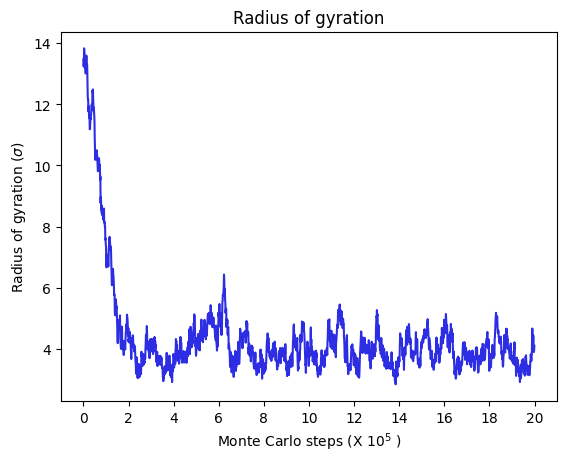

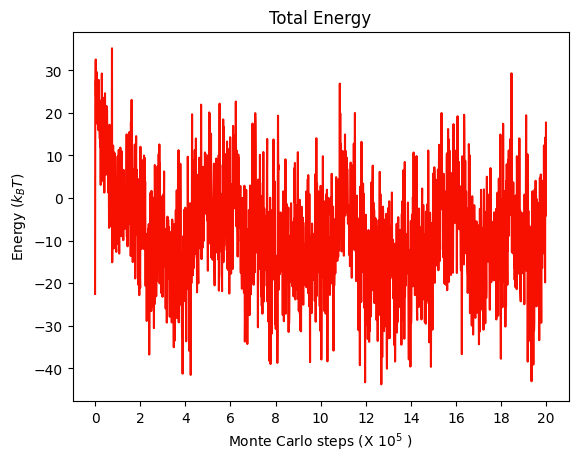

In [ ]:
## Importing necessary package modules
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
### Parameters of the simulation
N=100 ## No. of beads
freq=1000; ## Frequency of sampling
Rg=[] ## List variable to store the trajectory of rg

### Positions file
df= pd.read_csv("pos.xyz",delimiter=" ",names=["type","x","y","z"])
lines=len(df.index) ## Gives the number of lines in a file
i=2
while i<lines:

    j=i+N;
    frame=df[i:j]  ## Frame in the trajectory
    frame = frame[frame.columns[1:]].to_numpy()
    com = np.average(frame, axis=0)  ## Centre of mass

    r2 = np.sum((frame - com)**2, axis=1) ## Squared distance

    rg = np.sqrt(np.mean(r2))  ## Radius of gyration for the given timepoint
    Rg.append(rg) ## List of rg values for various time points

    i=i+N+2

time=[i*freq for i in range(len(Rg))]
plt.figure(1)
plt.plot(time,Rg,color="#2d2de3")
plt.title("Radius of gyration")
plt.xticks([0,2e5,4e5,6e5,8e5,1e6,12e5,14e5,16e5,18e5,2e6],[0,2,4,6,8,10,12,14,16,18,20])

plt.xlabel("Monte Carlo steps (X $10^{5}$ )")
plt.ylabel("Radius of gyration ($\sigma$)")

## Energy file
ene=np.loadtxt("energy.txt")
plt.figure(2)
plt.plot(ene[:,0],ene[:,1],color="#f70f00")
plt.title("Total Energy")
plt.xticks([0,2e5,4e5,6e5,8e5,1e6,12e5,14e5,16e5,18e5,2e6],[0,2,4,6,8,10,12,14,16,18,20])
plt.xlabel("Monte Carlo steps (X $10^{5}$ )")
plt.ylabel("Energy ($k_BT$)")


# Analysis: Contact probability
To extract contact probability we define a cut-off radius ($r_c$). If the 3D distance ($r_{ij}$) between two non-bonded beads ($i,j$) in the polymer structure is within the cut-off radius, we consider them to be in contact ($c_{ij}=1$).

\begin{align}
c_{ij} =
\begin{cases}
1 & r_{ij} \leq r_{c}  \\
0 & r_{ij} > r_{c}
\end{cases}
\end{align}

Now,

$$P(s)=\frac{\sum_{i,j} c_{ij}\delta(|i-j|-s)}{\sum_{i,j} \delta(|i-j|-s)}$$



In [ ]:
%%writefile contact_prob.c
#include<stdio.h>
#include<stdlib.h>
#define NINT(a) ((a) >= 0.0 ? (int)((a)+0.5) : (int)((a)-0.5))	//Nearest integer
#include<math.h>
#define Sqr(x)     ((x) * (x))

int main()
{
int i,j,k;
int ii;
int n;
int N;
N=100;
int s[N];
int t,nn;
int count,ncount;
int s_count[N];
int n_ens;
int seg;
int nframes;
double P[N][N];
double sum;
double s_P[N];
double x[N],y[N],z[N];
double xr,yr,zr,rr;
double sigma,rc,rc2;
FILE *ip,*op;
char file[100];
sigma=1.0;
rc=1.5*sigma;
rc2=rc*rc;
nframes=2000;
n_ens=0;
count=0;

  for(i=0;i<N;i++)
  {
    for(j=0;j<N;j++)
    {
    P[i][j]=0.0;
    s_count[i]=0;
    s_P[i]=0.0;
    }
  }

    sprintf(file,"pos.xyz");
    ip=fopen(file,"r");
    ncount=0;
    if(ip==NULL)printf("ERROR: File %s not found\n",file);
    while(ncount!=(N+2)*nframes)
    {
    ncount=ncount+N+2;
    fscanf(ip,"%d\n",&nn);
    fscanf(ip,"%d\n",&t);
        for(i=0;i<N;i++)
        {
        fscanf(ip,"%d %lf %lf %lf\n",&s[i],&x[i],&y[i],&z[i]);
        }
        if(ncount>(N+2)*300 ) //For averaging system equilibrates after 200 snapshots
        {
        n_ens++;
            for(i=0;i<N-1;i++)
            {
    	        for(j=i+1;j<N;j++)
	            {
	            xr=x[i]-x[j];
	            yr=y[i]-y[j];
	            zr=z[i]-z[j];
	            rr=xr*xr+yr*yr+zr*zr;
	                if(rr<rc2)
	                {
                    P[i][j]+=1.0;
                    P[j][i]+=1.0;
	                }
              }
            }
        }
    }
  fclose(ip);

    sprintf(file,"pc.txt");
    op=fopen(file,"w");
    for(i=0;i<N;i++)
    {
        for(j=0;j<N;j++)
        {
            P[i][j]=P[i][j]/(double)n_ens;
            fprintf(op,"%lf ",P[i][j]);
        }
        fprintf(op,"\n");
    }
    fclose(op);

    for(i=0;i<N-1;i++)
    {
        for(j=i+1;j<N;j++)
        {
            s_P[j-i]+=P[i][j];
            s_count[j-i]++;
        }
    }
    sprintf(file,"pc_S.dat");
    op=fopen(file,"w");
    for(i=0;i<N;i++)
        fprintf(op,"%lf\n",s_P[i]/(double)s_count[i]);
    fclose(op);

return 0;
}

Overwriting contact_prob.c


In [ ]:
!gcc contact_prob.c -lm -o pc.out
!./pc.out

# Contact Probability heatmap

Here we generate two visualizations related to contact probability:

**Heatmap**: The first figure plots a heatmap representing a contact probability matrix (cp), loaded from a text file.
The matrix is displayed with a logarithmic color scale using shades of red to indicate varying probabilities.

**Log-Log Plot**: The second plot shows the decay of contact probability (ps) with contour length (s) on a log-log scale.

Text(10, 0.1, '$S^{-1.5}$')

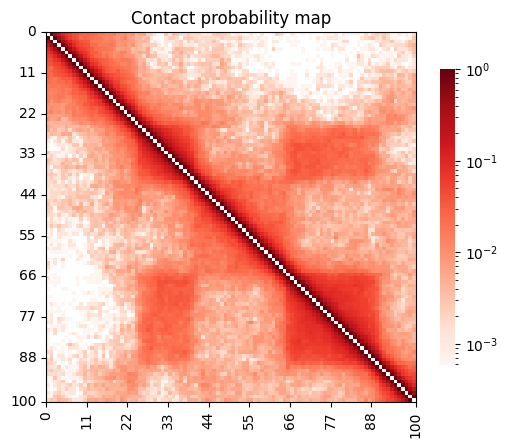

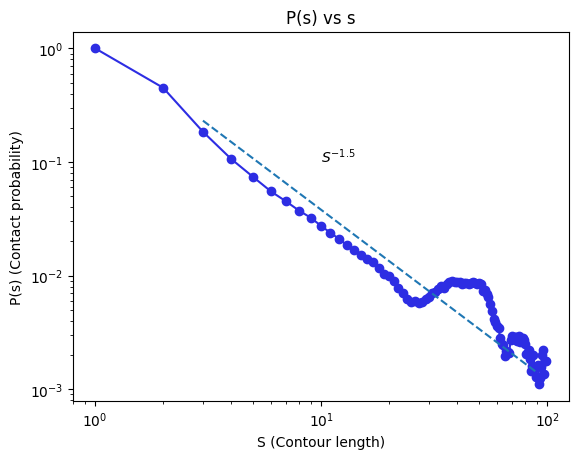

In [ ]:
### Contact Probability heatmap

import seaborn as sns
from matplotlib.colors import LogNorm
cp=np.loadtxt("pc.txt") ## N x N matrix of numpy array
ps=np.loadtxt("pc_S.dat")
plt.figure(1)

cmap = sns.color_palette("Reds", as_cmap=True) ## Color bar
ax =sns.heatmap(cp, annot=False, cmap=cmap, norm=LogNorm(), square=True, cbar_kws={'shrink': .8})
ticks = np.linspace(0, N, 10, dtype=int)
labels=[str(i) for i in ticks]
for spine in ax.spines.values():
    spine.set_visible(True)
ax.set_title("Contact probability map")
ax.set_xticks(ticks,labels)
ax.set_yticks(ticks,labels)

plt.figure(2)

guide=[1.2*np.power(i,-1.5) for i in range(3,N-10)]
plt.loglog(range(1,N),ps[1:],"o-",color="#2d2de3")
plt.loglog(range(3,N-10),guide,linestyle='dashed')
plt.title("P(s) vs s")
plt.xlabel("S (Contour length)")
plt.ylabel("P(s) (Contact probability)")
plt.text(10,0.1,r"$S^{-1.5}$")

# Visualization of polymer configurations

In this code we load multiple frames from an XYZ file and creates a 3D animation of a polymer structure, displaying smooth interpolated movement of atoms and saving the animation as a GIF.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import interp1d
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib import cm

# Function to load the multiple-frame XYZ file
def load_xyz_frames(filename):
    with open(filename, 'r') as f:
        frames = []
        while True:
            try:
                num_atoms = int(f.readline().strip())  # Number of atoms
                f.readline()  # Skip the comment line
                coords = np.array([list(map(float, f.readline().split()[1:])) for _ in range(num_atoms)])
                frames.append(coords)
            except:
                break
    return frames

# Load the frames from the XYZ file
frames = load_xyz_frames('pos.xyz')

# Determine the global min and max coordinates for axis limits
all_x = np.concatenate([frame[:, 0] for frame in frames])
all_y = np.concatenate([frame[:, 1] for frame in frames])
all_z = np.concatenate([frame[:, 2] for frame in frames])

x_min, x_max = all_x.min(), all_x.max()
y_min, y_max = all_y.min(), all_y.max()
z_min, z_max = all_z.min(), all_z.max()

# Padding for better visualization
padding = 5
ax_xlim = [x_min - padding, x_max + padding]
ax_ylim = [y_min - padding, y_max + padding]
ax_zlim = [z_min - padding, z_max + padding]

# Prepare the figure and 3D axis
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Initialize a line object for the polymer
line, = ax.plot([], [], [], c='red', lw=2)
scatter = ax.scatter([], [], [], c=[], s=50, cmap=cm.viridis)

# Set up the plot limits, labels, and title
ax.set_xlim(ax_xlim)
ax.set_ylim(ax_ylim)
ax.set_zlim(ax_zlim)
ax.set_xlabel('X', fontsize=15)
ax.set_ylabel('Y', fontsize=15)
ax.set_zlabel('Z', fontsize=15)
plt.title('3D Visualization of Polymer Structure', fontsize=20)
#plt.legend(loc='best')

# Remove the axis grid and ticks
ax.grid(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

# Set the best viewing angle
ax.view_init(elev=20, azim=120)

# Update function for the animation
def update(frame):
    x = frame[:, 0]
    y = frame[:, 1]
    z = frame[:, 2]

    # Interpolate the points
    t = np.linspace(0, 1, len(x))
    interp_t = np.linspace(0, 1, 10 * len(x))  # More points for smoothness

    interp_x = interp1d(t, x, kind='cubic')(interp_t)
    interp_y = interp1d(t, y, kind='cubic')(interp_t)
    interp_z = interp1d(t, z, kind='cubic')(interp_t)

    # Update the line plot
    line.set_data(interp_x, interp_y)
    line.set_3d_properties(interp_z)

    # Set bead colors based on position along the length
    color_values = np.linspace(0, 1, len(x))

    scatter._offsets3d = (x, y, z)
    scatter.set_array(color_values)

    return line, scatter

# Create the animation
ani = FuncAnimation(fig, update, frames=frames, interval=200, blit=True)

# Save the animation using PillowWriter
writer = PillowWriter(fps=5)
ani.save('polymer_animation.gif', writer=writer)

plt.show()
